# 01 — Data Preprocessing

Load the LinkedIn Job Postings dataset, clean, filter, and explore.

In [1]:
!pip install kagglehub pandas matplotlib

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('arshkon/linkedin-job-postings')
print(f'Downloaded to: {path}')
print(os.listdir(path))

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Downloaded to: /kaggle/input/linkedin-job-postings
['companies', 'mappings', 'jobs', 'postings.csv']


## Load & Inspect

In [3]:
# Adjust filename as needed
df = pd.read_csv(os.path.join(path, 'postings.csv'))
print(f'Shape: {df.shape}')
df.head()

Shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## Clean & Filter

In [4]:
# Remove rows missing critical columns
df = df.dropna(subset=['title', 'description', 'formatted_experience_level'])
print(f'After cleaning: {len(df)} records')
print(df['formatted_experience_level'].value_counts())

After cleaning: 94440 records
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64


## Label Mapping

In [5]:
label_map = {
    'Entry level': 'junior',
    'Internship': 'junior',
    'Associate': 'mid',
    'Mid-Senior level': 'mid',
    'Director': 'senior',
    'Executive': 'senior'
}
df['experience_class'] = df['formatted_experience_level'].map(label_map)
df = df.dropna(subset=['experience_class'])  # drop unmapped
print(f'Final: {len(df)} records')
df['experience_class'].value_counts()

Final: 94440 records


,count
experience_class,
mid,51315
junior,38157
senior,4968


## EDA

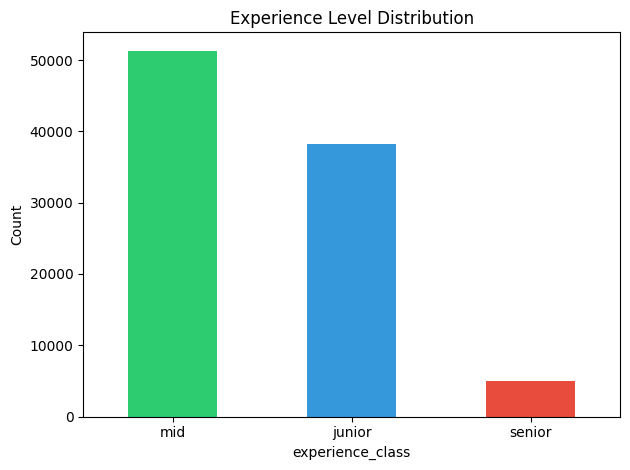

In [6]:
import matplotlib.pyplot as plt

df['experience_class'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'])
plt.title('Experience Level Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Save Cleaned Dataset

In [7]:
df.to_csv('cleaned_postings.csv', index=False)
print(f'Saved {len(df)} records')

Saved 94440 records
